<a href="https://colab.research.google.com/github/omkeshborse/Face-Scan-Poc/blob/main/shenpoc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/nasir6/rPPG.git
%cd rPPG
!ls

Cloning into 'rPPG'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 113 (delta 41), reused 41 (delta 41), pack-reused 61 (from 1)
Receiving objects: 100% (113/113), 6.24 MiB | 20.10 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/rPPG
asf.py		   fft_spec.npy  models.py	  pulse.py	    results.png
capture_frames.py  hrs.npy	 plot_cont.py	  __pycache__	    run.py
cdf.py		   images	 process_mask.py  README.md	    utils.py
FaceSeg.py	   linknet.pth	 pulse.npy	  requirements.txt  wavelet.py


In [4]:
!pip install torch torchvision -q
!pip install opencv-python-headless -q
!pip install numpy scipy matplotlib pillow neurokit2 -q
print('✅ Dependencies installed')

✅ Dependencies installed


In [5]:
!pip install gdown -q
import gdown, os

gdown.download('https://drive.google.com/uc?id=1shRnrUAF5HyA_vwXJfCcrNVFkltT7U5E', 'linknet.pth', quiet=False)
print(f'✅ Downloaded linknet.pth — {os.path.getsize("linknet.pth")/1e6:.1f} MB')

Downloading...
From: https://drive.google.com/uc?id=1shRnrUAF5HyA_vwXJfCcrNVFkltT7U5E
To: /content/rPPG/linknet.pth
100%|██████████| 87.3M/87.3M [00:00<00:00, 252MB/s]


✅ Downloaded linknet.pth — 87.3 MB


In [6]:
from google.colab import files

print('📁 Upload your video')
uploaded = files.upload()
video_filename = list(uploaded.keys())[0]
print(f'✅ Uploaded: {video_filename}')

📁 Upload your video


Saving 20260314_144208.mp4 to 20260314_144208.mp4
✅ Uploaded: 20260314_144208.mp4


In [7]:
import os

output_file = 'input_video.avi'
os.system(f'ffmpeg -i "{video_filename}" -c:v libx264 -x264opts "keyint=1:min-keyint=1" -an "{output_file}" -y')
print(f'✅ Re-encoded: {output_file}')

✅ Re-encoded: input_video.avi


In [8]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Fix 1 — matplotlib TkAgg to Agg
with open('plot_cont.py', 'r') as f:
    code = f.read()
code = code.replace("matplotlib.use('TkAgg')", "matplotlib.use('Agg')")
code = code.replace('matplotlib.use("TkAgg")', 'matplotlib.use("Agg")')
with open('plot_cont.py', 'w') as f:
    f.write(code)

# Fix 2 — cv2 headless
with open('capture_frames.py', 'r') as f:
    code = f.read()
code = code.replace('k = cv2.waitKey(1)', 'k = -1')
code = code.replace('cv2.imshow', 'pass  #')
code = code.replace('cv2.destroyAllWindows()', 'pass')
code = code.replace("torch.load('linknet.pth')", f"torch.load('linknet.pth', map_location='{device}')")
code = code.replace("map_location='cuda'", f"map_location='{device}'")
with open('capture_frames.py', 'w') as f:
    f.write(code)

# Fix 3 — patch process_mask.py to save full signal
with open('process_mask.py', 'r') as f:
    code = f.read()
code = code.replace(
    'self.hrs = []\n        self.save_results = True',
    'self.hrs = []\n        self.save_results = True\n        self.full_signal = np.zeros((0, 3))'
)
code = code.replace(
    "            if mean_dict['face_detected'] == False:\n                if self.plot_pipe is not None:\n                    self.plot_pipe.send('no face detected')\n                continue\n            if signal_extracted >= self.signal_size:",
    "            if mean_dict['face_detected'] == False:\n                if self.plot_pipe is not None:\n                    self.plot_pipe.send('no face detected')\n                continue\n            self.full_signal = np.vstack([self.full_signal, mean]) if self.full_signal.shape[0] > 0 else mean\n            if signal_extracted >= self.signal_size:"
)
code = code.replace(
    "np.save('fft_spec', np.array(self.pulse.fft_spec))",
    "np.save('fft_spec', np.array(self.pulse.fft_spec))\n        np.save('full_signal', self.full_signal)"
)
with open('process_mask.py', 'w') as f:
    f.write(code)

print(f'✅ Device: {device}')
print('✅ All fixes applied')

✅ Device: cpu
✅ All fixes applied


In [9]:
!python run.py --source=input_video.avi --frame-rate=30

init
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100% 83.3M/83.3M [00:00<00:00, 140MB/s]
FPS: 1.754120640543037time 1021.2865183353424


In [10]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

hrs = np.load('hrs.npy')

print(f'Mean HR : {np.mean(hrs):.1f} BPM')
print(f'Min HR  : {np.min(hrs):.1f} BPM')
print(f'Max HR  : {np.max(hrs):.1f} BPM')

plt.figure(figsize=(14, 4))
plt.plot(hrs, color='royalblue', linewidth=2, marker='o', markersize=4)
plt.axhline(np.mean(hrs), color='red', linestyle='--', label=f'Mean: {np.mean(hrs):.1f} BPM')
plt.title('Heart Rate Over Time')
plt.xlabel('Batch')
plt.ylabel('BPM')
plt.ylim(0, 180)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hr_plot.png', dpi=150)
plt.show()
print('✅ Saved hr_plot.png')

Mean HR : 61.3 BPM
Min HR  : 54.3 BPM
Max HR  : 81.5 BPM
✅ Saved hr_plot.png


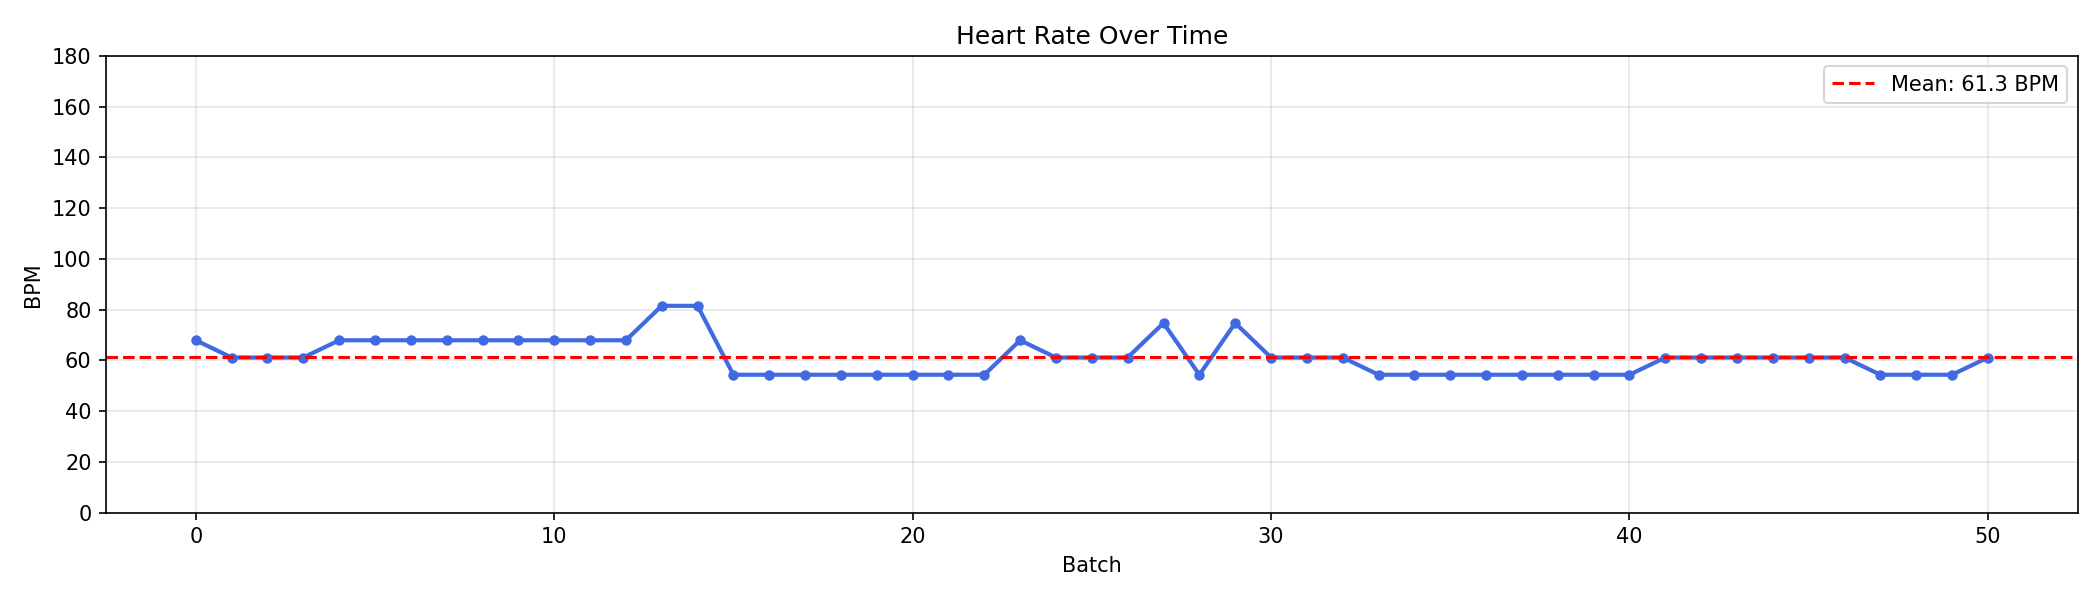

In [12]:
from IPython.display import Image
Image('hr_plot.png')

In [14]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.fft import fft, fftfreq

fps = 30
full_signal = np.load('full_signal.npy')
green = full_signal[:, 1].astype(float)
hrs = np.load('hrs.npy')
mean_hr = np.mean(hrs)

def bandpass(sig, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)

# Very narrow bandpass — only pass HR frequency ±20%
# this removes breathing modulation AND double hump
hr_hz = mean_hr / 60
low  = hr_hz * 0.80
high = hr_hz * 1.20
print(f'HR: {mean_hr:.1f} BPM = {hr_hz:.3f} Hz')
print(f'Bandpass: {low:.3f} – {high:.3f} Hz')

green_narrow = bandpass(green, low, high, fps)
green_norm = (green_narrow - np.mean(green_narrow)) / np.std(green_narrow)

# with narrow bandpass signal is now clean sine wave
# use generous distance
min_dist = int((60 / mean_hr) * fps * 0.75)
peaks, _ = find_peaks(green_norm, distance=min_dist, prominence=0.3)

rr = np.diff(peaks) / fps * 1000
median_rr = np.median(rr)
rr_clean = rr[(rr > median_rr * 0.80) & (rr < median_rr * 1.20)]

print(f'\nPeaks found    : {len(peaks)}')
print(f'Expected beats : ~{int(mean_hr * len(green)/fps/60)}')
print(f'Median RR      : {median_rr:.0f}ms  ({60000/median_rr:.1f} BPM)')
print(f'RR std         : {rr_clean.std():.0f}ms  (target <100ms)')

# HRV
rmssd = np.sqrt(np.mean(np.diff(rr_clean) ** 2))
sdnn  = np.std(rr_clean)
nn50  = np.sum(np.abs(np.diff(rr_clean)) > 50)
pnn50 = (nn50 / len(rr_clean)) * 100 if len(rr_clean) > 1 else 0

# breathing
breath_signal = bandpass(green, 0.1, 0.5, fps)
breath_peaks, _ = find_peaks(breath_signal, distance=fps*2, prominence=0.1)
breathing_rate = len(breath_peaks) / (len(green) / fps / 60)

# LF/HF
freqs    = fftfreq(len(rr_clean), np.mean(rr_clean)/1000)
fft_vals = np.abs(fft(rr_clean)) ** 2
lf_power = np.sum(fft_vals[(freqs >= 0.04) & (freqs <= 0.15)])
hf_power = np.sum(fft_vals[(freqs >= 0.15) & (freqs <= 0.40)])
lf_hf    = lf_power / hf_power if hf_power > 0 else 0

# plot
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
show = 600
axes[0].plot(green_norm[:show], color='green', linewidth=0.8, label='Narrow BVP signal')
p_show = peaks[peaks < show]
axes[0].plot(p_show, green_norm[p_show], 'rv', markersize=8, label=f'{len(peaks)} peaks')
axes[0].set_title(f'Narrow bandpass ({low:.2f}–{high:.2f} Hz) — should be clean sine')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rr_clean, color='royalblue', linewidth=1.5, marker='o', markersize=5)
axes[1].axhline(median_rr, color='red', linestyle='--', label=f'Median: {median_rr:.0f}ms')
axes[1].set_title(f'RR Intervals — Std: {rr_clean.std():.0f}ms  (target <100ms)')
axes[1].set_ylabel('ms')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rr_narrow.png', dpi=150)
plt.show()

from google.colab import files
files.download('rr_narrow.png')

# report
print('\n' + '=' * 45)
print('        FULL VITALS REPORT')
print('=' * 45)
print(f' Heart Rate      : {mean_hr:.1f} BPM')
print(f' RMSSD           : {rmssd:.2f} ms  (normal: 20-50ms)')
print(f' SDNN            : {sdnn:.2f} ms  (normal: 50-100ms)')
print(f' pNN50           : {pnn50:.2f} %  (normal: 3-45%)')
print(f' LF/HF           : {lf_hf:.2f}  (normal: 1-2)')
if lf_hf < 1.5:
    print('Stress Status   : Relaxed')
elif lf_hf < 3.0:
    print('Stress Status   : Balanced')
else:
    print('Stress Status   : Stressed')
print(f'Breathing Rate  : {breathing_rate:.1f} breaths/min')
print(f'Duration        : {len(green)/fps:.1f} seconds')
print('=' * 45)

HR: 61.3 BPM = 1.021 Hz
Bandpass: 0.817 – 1.225 Hz

Peaks found    : 56
Expected beats : ~61
Median RR      : 1000ms  (60.0 BPM)
RR std         : 71ms  (target <100ms)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


        FULL VITALS REPORT
 Heart Rate      : 61.3 BPM
 RMSSD           : 70.62 ms  (normal: 20-50ms)
 SDNN            : 71.29 ms  (normal: 50-100ms)
 pNN50           : 39.13 %  (normal: 3-45%)
 LF/HF           : 1.54  (normal: 1-2)
Stress Status   : Balanced
Breathing Rate  : 21.0 breaths/min
Duration        : 60.0 seconds


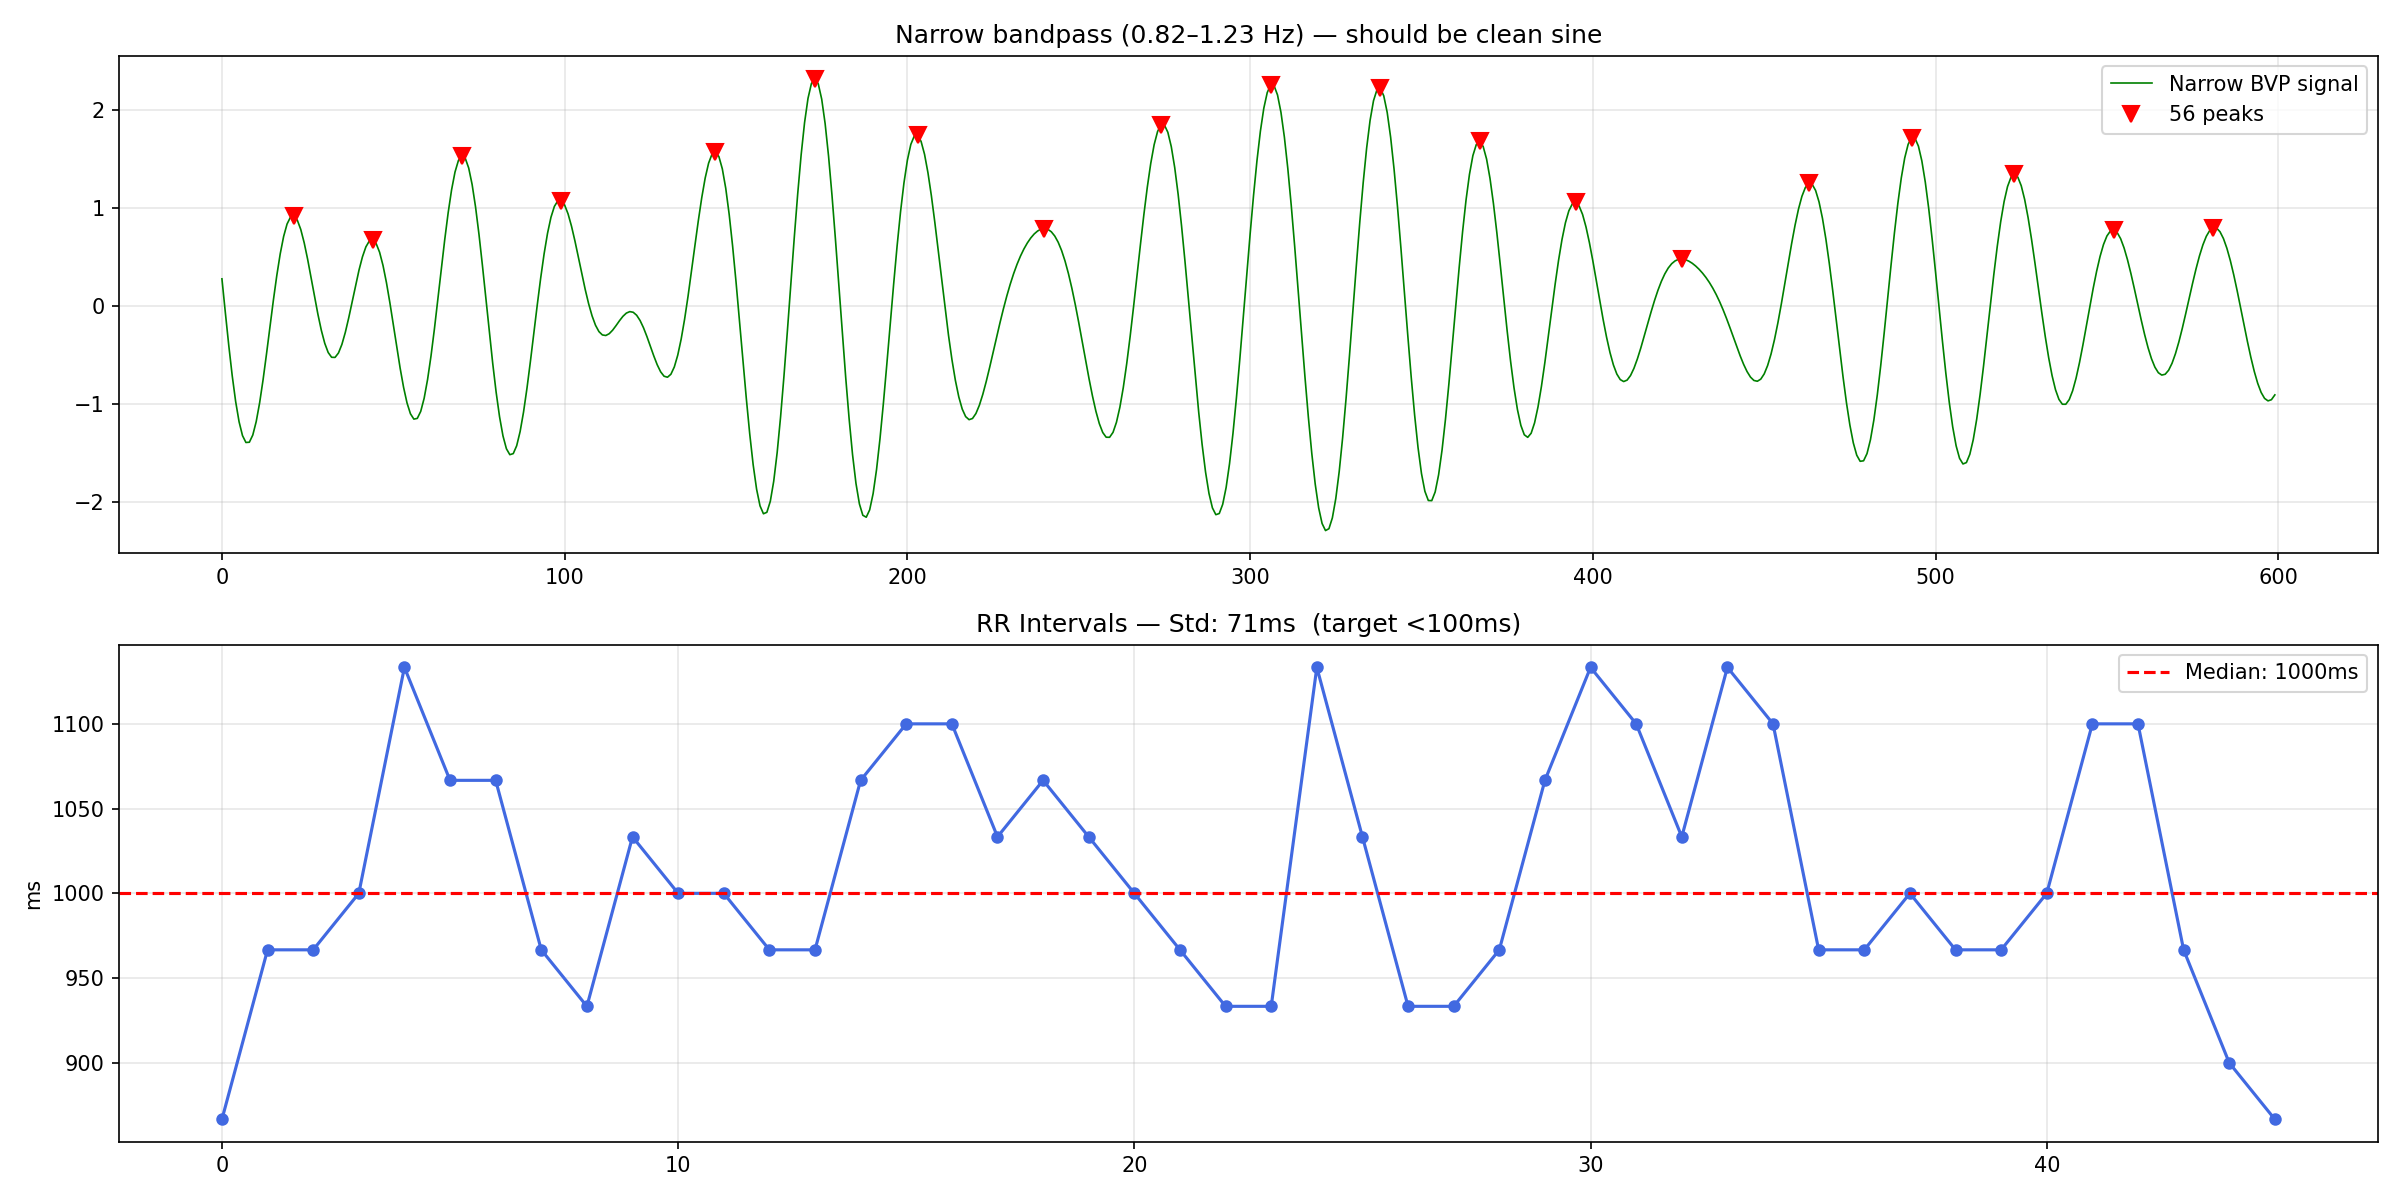

In [15]:
# show any image
from IPython.display import Image
Image('hr_plot.png')        # HR plot
Image('results.png')        # toolbox result
Image('rr_narrow.png')      # final RR intervals